In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(arrow)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




ERROR: Error in library(arrow): there is no package called ‘arrow’


In [4]:
install.packages("arrow",lib="/dfs3b/ruic20_lab/junw42/software/R_package")

Warning message in install.packages("arrow", lib = "/dfs3b/ruic20_lab/junw42/software/R_package"):
“installation of package ‘arrow’ had non-zero exit status”


In [5]:
od="20250620_PP_comb" #args[1]
target_tissue="ONONH" #args[2]
path0="20250620__203138__Human_70y_ASRetina_20250620" #args[3]
kw="PP_" #args[4]
cb_dir="/dfs3b/ruic20_lab/junw42/HCA_ON/data/8_spatial/Xenium/" #args[5]
id="3" #args[6]


In [6]:
wd=paste0("/dfs3b/ruic20_lab/junw42/HCA_ON/data/8_spatial/Xenium/",od)
setwd(wd)

In [7]:
output_PATH <- paste0(wd, "/",target_tissue, "/")
dir.create(output_PATH, recursive = TRUE)

In [10]:
path=paste0("/dfs3b/ruic20_lab/rawdata/Xenium/",path0) 
matching_dirs0 <- list.dirs(path, full.names = TRUE, recursive = FALSE)
xenium_data_list <- list()
matching_dirs=matching_dirs0[grepl(kw,matching_dirs0)]

In [11]:
matching_dirs

[1] "/dfs3b/ruic20_lab/rawdata/Xenium/20250620__203138__Human_70y_ASRetina_20250620/output-XETG00221__0068480__25-019211OS_PP_01__20250620__203217"
[2] "/dfs3b/ruic20_lab/rawdata/Xenium/20250620__203138__Human_70y_ASRetina_20250620/output-XETG00221__0068480__25-019211OS_PP_02__20250620__203217"

In [12]:
for (i in c(1:length(matching_dirs))){
  
  dir <- paste0(kw, i)
  xenium_path_full <- matching_dirs[i]
  print(xenium_path_full)

  # adjust to new version of xenium ranger, which dropping transcripts.csv.gz in the output folder
  #transcripts <- read_parquet(file.path(xenium_path_full, "transcripts.parquet"))
  #write.csv(transcripts, gzfile(file.path(xenium_path_full, "transcripts.csv.gz")), row.names = FALSE)

  xenium.obj <- LoadXenium(xenium_path_full, fov = "fov")
  print(dim(xenium.obj))
  xenium.obj@meta.data$slide_id <- dir 
  print(quantile(xenium.obj$nCount_Xenium, seq(0, 1, 0.1)))
  print(quantile(xenium.obj$nFeature_Xenium, seq(0, 1, 0.1)))

#  if (target_tissue == "Surface"){
    cell_id_PATH <- paste0(cb_dir,"/",matching_dirs[i])
    cell_list_list <- list()
#    j <- 1
 #   for (tissue in c("Cornea", "Limbus", "Sclera")){
#      cell_list_file <- paste0(cell_id_PATH, tissue, "/",  "sec0", i, "_", tissue, "_cells_id.txt")
      cell_list_file <- paste0(cell_id_PATH, "/",  "Selection_",id,"_cells_stats.csv")

      cell_list <- read.table(cell_list_file, header = T,comment.char = "#",sep=",")
      cell_list_list[[j]] <- cell_list[,1]
#      j <- j + 1
#    }
    cell_list <- do.call(rbind, cell_list_list)

    xenium.obj@meta.data$barcode <- rownames(xenium.obj@meta.data)
  xenium.obj <- subset(xenium.obj, subset = barcode %in% cell_list$V1)
  print(dim(xenium.obj))

  print(quantile(xenium.obj$nCount_Xenium, seq(0, 1, 0.1)))
  print(quantile(xenium.obj$nFeature_Xenium, seq(0, 1, 0.1)))

  xenium.obj <- subset(xenium.obj, subset = nCount_Xenium > 20)
  print(dim(xenium.obj))

  xenium.obj@meta.data$cell_size <- sapply(rownames(xenium.obj@meta.data), FUN = function(x){xenium.obj@images$fov$segmentation[x]@polygons[[1]]@area})

  xenium_data_list[[i]] <- xenium.obj
  names(xenium_data_list)[i] <- unlist(strsplit(dir, split = "_"))[1]

}


[1] "/dfs3b/ruic20_lab/rawdata/Xenium/20250620__203138__Human_70y_ASRetina_20250620/output-XETG00221__0068480__25-019211OS_PP_01__20250620__203217"


10X data contains more than one type and is being returned as a list containing matrices of each type.

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


[1]   478 54733
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0    9   22   37   56   80  109  145  195  283 2467 
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0    6   12   19   25   32   39   47   58   77  189 


Warning message in file(file, "rt"):
“cannot open file '/dfs3b/ruic20_lab/junw42/HCA_ON/data/8_spatial/Xenium///dfs3b/ruic20_lab/rawdata/Xenium/20250620__203138__Human_70y_ASRetina_20250620/output-XETG00221__0068480__25-019211OS_PP_01__20250620__203217/Selection_3_cells_stats.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [15]:
md=strsplit(matching_dirs[1], "/")

In [25]:
strsplit(matching_dirs[1], "/")

list()

In [26]:
basename(normalizePath(matching_dirs[1]))

[1] "output-XETG00221__0068480__25-019211OS_PP_01__20250620__203217"

In [44]:
xenium_data_list <- list()
matching_dirs=matching_dirs0[grepl(kw,matching_dirs0)]
for (i in c(1:length(matching_dirs))){

  dir <- paste0(kw, i)
  xenium_path_full <- matching_dirs[i]
  print(xenium_path_full)

  # adjust to new version of xenium ranger, which dropping transcripts.csv.gz in the output folder
  #transcripts <- read_parquet(file.path(xenium_path_full, "transcripts.parquet"))
  #write.csv(transcripts, gzfile(file.path(xenium_path_full, "transcripts.csv.gz")), row.names = FALSE)

  xenium.obj <- LoadXenium(xenium_path_full, fov = "fov")
  print(dim(xenium.obj))
  xenium.obj@meta.data$slide_id <- dir #unlist(strsplit(dir, split = "_"))[1]

  #pdf(paste0("basic_analysis/", dir, "_basic.pdf"))
  #p <- ImageFeaturePlot(xenium.obj, fov = "fov", features = "nCount_Xenium", max.cutoff = "q90") +
  #  theme(
  #    panel.grid = element_blank(),
  #    panel.border = element_blank(),
  #    axis.ticks = element_blank(),
  #    axis.text = element_blank()
  #  )
  #print(p)
  #p <- ImageFeaturePlot(xenium.obj, fov = "fov", features = "nFeature_Xenium", max.cutoff = "q90") +
  #  theme(
  #    panel.grid = element_blank(),
  #    panel.border = element_blank(),
  #    axis.ticks = element_blank(),
  #    axis.text = element_blank()
  #  )
  #print(p)
  #dev.off()

  print(quantile(xenium.obj$nCount_Xenium, seq(0, 1, 0.1)))
  print(quantile(xenium.obj$nFeature_Xenium, seq(0, 1, 0.1)))
 md=basename(normalizePath(matching_dirs[i]))
#  if (target_tissue == "Surface"){
    cell_id_PATH <- paste0(cb_dir,"/",md)

 #    cell_id_PATH <- paste0(cb_dir,"/",matching_dirs[i])
    cell_list_list <- list()
    j <- 1
 #   for (tissue in c("Cornea", "Limbus", "Sclera")){
#      cell_list_file <- paste0(cell_id_PATH, tissue, "/",  "sec0", i, "_", tissue, "_cells_id.txt")
      cell_list_file <- paste0(cell_id_PATH, "/",  "Selection_",id,"_cells_stats.csv")

      cell_list <- read.table(cell_list_file, header = T,comment.char = "#",sep=",")
      cell_list_list[[j]] <- cell_list
#      j <- j + 1
#    }
    cell_list <- do.call(rbind, cell_list_list)
    
    xenium.obj@meta.data$barcode <- rownames(xenium.obj@meta.data)
  xenium.obj <- subset(xenium.obj, subset = barcode %in% cell_list[,1])
  print(dim(xenium.obj))

  print(quantile(xenium.obj$nCount_Xenium, seq(0, 1, 0.1)))
  print(quantile(xenium.obj$nFeature_Xenium, seq(0, 1, 0.1)))

  xenium.obj <- subset(xenium.obj, subset = nCount_Xenium > 20)
  print(dim(xenium.obj))

  xenium.obj@meta.data$cell_size <- sapply(rownames(xenium.obj@meta.data), FUN = function(x){xenium.obj@images$fov$segmentation[x]@polygons[[1]]@area})

  xenium_data_list[[i]] <- xenium.obj
  names(xenium_data_list)[i] <- unlist(strsplit(dir, split = "_"))[1]

}


[1] "/dfs3b/ruic20_lab/rawdata/Xenium/20250620__203138__Human_70y_ASRetina_20250620/output-XETG00221__0068480__25-019211OS_PP_01__20250620__203217"


10X data contains more than one type and is being returned as a list containing matrices of each type.

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


[1]   478 54733
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0    9   22   37   56   80  109  145  195  283 2467 
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0    6   12   19   25   32   39   47   58   77  189 


Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


[1]   478 32118
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0    8   21   36   52   72   95  122  156  212 2467 
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0    6   13   19   25   31   36   43   50   60  165 


...

[1]   478 51167
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0   17   35   53   74   97  121  149  185  248 1945 
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0   10   18   24   30   35   41   47   55   67  147 


Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


[1]   478 27408
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0   14   29   44   60   79  101  127  158  208 1351 
  0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
   0    9   16   22   27   32   38   43   50   59  139 


Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


[1]   478 23509


In [42]:
length(cell_list[,1])

[1] 32118

In [33]:
cell_list_file

[1] "/dfs3b/ruic20_lab/junw42/HCA_ON/data/8_spatial/Xenium//output-XETG00221__0068480__25-019211OS_PP_02__20250620__203217/Selection_3_cells_stats.csv"

In [35]:
xenium.obj

An object of class Seurat 
541 features across 51167 samples within 4 assays 
Active assay: Xenium (478 features, 0 variable features)
 1 layer present: counts
 3 other assays present: BlankCodeword, ControlCodeword, ControlProbe
 1 spatial field of view present: fov

In [41]:
cell_list[,1]

[1] "nannpgke-1" "lcpjamai-1" "linggmpa-1" "kdodkheo-1" "kelnidba-1"
    [6] "kekjopnh-1" "keodcede-1" "kenapmng-1" "kemoknif-1" "keobbkac-1"
   [11] "kemlhcoj-1" "oeomggej-1" "keniholl-1" "kemlgfij-1" "kenkdllj-1"
   [16] "kenjeaci-1" "keneokao-1" "keoiknib-1" "keomkokl-1" "keommncd-1"
   [21] "keomjpdb-1" "keoipjbj-1" "kemjhbpa-1" "kemeipkg-1" "kepiaegp-1"
   [26] "keplaigk-1" "kemdejmm-1" "kemghbfj-1" "kephongj-1" "kepjacpi-1"
   [31] "kemkkenk-1" "keocdhnj-1" "keoafanf-1" "kenmlfkk-1" "kenlhfbb-1"
   [36] "kenpefcf-1" "kenlpopn-1" "kencbklp-1" "oepdagln-1" "keoecbkn-1"
   [41] "keonpaho-1" "kepcoblm-1" "kepfijjj-1" "keodiceo-1" "keoeifng-1"
   [46] "oepckllf-1" "kepmkgek-1" "kepkfjhd-1" "kemcaaoe-1" "kemdpjhe-1"
   [51] "kepjbclk-1" "kemccbgh-1" "kepjakel-1" "kemhddhf-1" "kfablpon-1"
   [56] "kepmngaf-1" "keppodhg-1" "kfaadgno-1" "kejkhgjd-1" "kejiibie-1"
   [61] "kekinlcc-1" "kekgcjkk-1" "kekikpjg-1" "kekhbicb-1" "keleondk-1"
   [66] "keleoidp-1" "kelhbjkp-1" "keleblml-1" "kejjmemk-1" "kekfncof-1"
   [71] "kekccoae-1" "kekdlmib-1" "kejpeklm-1" "oeolkpje-1" "kejjebie-1"
   [76] "kffgphla-1" "kfbpedfg-1" "kfajglce-1" "kfanljgk-1" "kfapojeh-1"
   [81] "kfakeaeg-1" "kfbgmehp-1" "kfananoa-1" "kfbjokcd-1" "kfajblml-1"
   [86] "keonjibo-1" "kepefdfo-1" "kepeoldb-1" "kfbjkppn-1" "kephfmdo-1"
   [91] "oepchemj-1" "kfbolnoh-1" "kfacngad-1" "oeomoheb-1" "kfaihajf-1"
   [96] "kfamkhff-1" "kfagdiei-1" "kfafonen-1" "kfandkao-1" "kfaflhmo-1"
  [101] "kepmjhob-1" "kfaokpij-1" "kfapnneo-1" "kfappdoc-1" "kfblmoen-1"
  [106] "kfbmbnfi-1" "kfbdfkba-1" "kfbbfomf-1" "kfcbdlmi-1" "kfbobgjp-1"
  [111] "kfbbjajp-1" "kfcdipnm-1" "keophoka-1" "kfbnhing-1" "kembbbbd-1"
  [116] "kfbngiol-1" "kfbpjcec-1" "kemaipbd-1" "kemajmjb-1" "kelnjncd-1"
  [121] "kembefok-1" "kelpooln-1" "kfchahkl-1" "kelonmfg-1" "kfgciaah-1"
  [126] "kfcgpble-1" "kfcnondc-1" "kfcinmhi-1" "kfchfngp-1" "kffnkfff-1"
  [131] "kfceefff-1" "kfcfpmcb-1" "kfcfnlel-1" "kfceabbm-1" "kfceboda-1"
  [136] "kfciflfc-1" "kfcpegdo-1" "kfcmeopa-1" "kfcjhkgo-1" "kfcnmccf-1"
  [141] "kfcohkbo-1" "kffhfael-1" "kfcppcfp-1" "kfcloopb-1" "kfikbgjm-1"
  [146] "kfiljjce-1" "kfinobbj-1" "kfihonkm-1" "kfilnbkk-1" "kfinhplm-1"
  [151] "ofaacfoi-1" "oepncgag-1" "kfhjkehm-1" "kficflde-1" "kficmjka-1"
  [156] "kfhjjfll-1" "kfgdojad-1" "kfgefnhp-1" "kfgdpdbj-1" "kfdiflgd-1"
  [161] "kffojoob-1" "kffkfddg-1" "oepdolip-1" "oepfimgh-1" "kfgchcpp-1"
  [166] "kffmplii-1" "kfgcbnjk-1" "kffpaipf-1" "kfgdflnc-1" "kfjbhoml-1"
  [171] "kfjbnbfe-1" "oeplbhgn-1" "kfjakfae-1" "kfjahlje-1" "kfioehbm-1"
  [176] "kfgjffie-1" "kfgfafbm-1" "kfgiloin-1" "kfgfbind-1" "kffcficn-1"
  [181] "kffbccom-1" "kgbofdlj-1" "kejoknom-1" "kejomijg-1" "khihibeh-1"
  [186] "khjcjgfp-1" "kejogmfk-1" "ofcklopb-1" "kggbbldj-1" "kgbmfnfd-1"
  [191] "ofbghhmp-1" "kgbobagh-1" "kfnfedlc-1" "kfnfknif-1" "kfofcjge-1"
  [196] "kfoedhdj-1" "khiinnbn-1" "kgejhlcn-1" "kgfcdkem-1" "kgfffbhl-1"
  [201] "kggampfm-1" "kggcoofd-1" "kgbolpko-1" "khoddoko-1" "kefdcgpb-1"
  [206] "kekpedon-1" "kefhmdil-1" "keffbncn-1" "keknhcmh-1" "kelaogne-1"
  [211] "kelcmfaf-1" "kelbhdml-1" "kejnlemd-1" "keknfiam-1" "kekkhhmc-1"
  [216] "kekjdfda-1" "keffhpeg-1" "kejpcgpk-1" "kefhamfh-1" "kefjmfmc-1"
  [221] "kekoecao-1" "ofcmdfik-1" "khnknhdo-1" "kefhokeb-1" "oeolgiih-1"
  [226] "khjonhpj-1" "kelnemme-1" "keffbfnp-1" "kefkpdac-1" "oeomgade-1"
  [231] "kelimian-1" "kfhifnbo-1" "khnepgdd-1" "kfhigmpp-1" "kfhilpbj-1"
  [236] "kfhmbpmh-1" "kfideflm-1" "kfhialfg-1" "kfihclbi-1" "kfhmhgie-1"
  [241] "kfiapaae-1" "khneobfa-1" "oepiicog-1" "khnhecbj-1" "kfielpmf-1"
  [246] "khnjhijf-1" "khnoaipe-1" "khnhekok-1" "khnnfpac-1" "ofenhgdc-1"
  [251] "khnmapgm-1" "khnjcmeh-1" "kfhpimbb-1" "kfhopfoh-1" "kfhmkkga-1"
  [256] "khnknogn-1" "kfhpgaai-1" "khiijakn-1" "kgbdngkk-1" "kgbcofji-1"
  [261] "kgbhgcpd-1" "kgbclpaj-1" "kgbjggaf-1" "khiphdop-1" "khiojckp-1"
  [266] "kgbfbhdo-1" "khiioopa-1" "khinfaih-1" "khifijpd-1" "khimgman-1"
  [271] "khiggelk-1" "khjcmoki-1" "kgbakodh-1" "kgbaaojg-1" "k

In [40]:
rownames(xenium.obj@meta.data)

[1] "aaaacffd-1" "aaabefhi-1" "aaabpolj-1" "aaacgpmf-1" "aaadgjbp-1"
    [6] "aaadnddc-1" "aaagieal-1" "aaagpoag-1" "aaaljkmb-1" "aaamggkg-1"
   [11] "aaancjip-1" "aaaoaboi-1" "aaaoalep-1" "aaapbiol-1" "aaapejbi-1"
   [16] "aaapmnil-1" "aabcpalc-1" "aabgdhaa-1" "aabgdiei-1" "aabgoole-1"
   [21] "aabhhpgd-1" "aabjbdem-1" "aabkffbn-1" "aabndcla-1" "aaboebhi-1"
   [26] "aacaamdo-1" "aaccejge-1" "aacdjgoa-1" "aachpbje-1" "aacjmbnk-1"
   [31] "aacjpfji-1" "aacljkkn-1" "aaclloek-1" "aacmldoh-1" "aacnnfld-1"
   [36] "aacolelk-1" "aadaofmo-1" "aadbjied-1" "aadbkpei-1" "aadcgogi-1"
   [41] "aadcpgic-1" "aaddibim-1" "aaddkccj-1" "aadeflkb-1" "aadgoncj-1"
   [46] "aadhplpj-1" "aadiiflc-1" "aadlmcip-1" "aadpdahd-1" "aadpiooj-1"
   [51] "aaebmjpd-1" "aaecboal-1" "aaedchcc-1" "aaedickd-1" "aaedobli-1"
   [56] "aaeffhae-1" "aaegdaic-1" "aaehabdo-1" "aaejagdg-1" "aaenebah-1"
   [61] "aaenhfda-1" "aaeoadlc-1" "aafbgffg-1" "aafcfiho-1" "aafchkgh-1"
   [66] "aafcppff-1" "aafdliib-1" "aaffjjmg-1" "aafflbjh-1" "aafgnnkm-1"
   [71] "aafhifah-1" "aafiinno-1" "aafippdp-1" "aafknddd-1" "aaflaikn-1"
   [76] "aafmecac-1" "aafnkpci-1" "aafnopjg-1" "aafnpbcb-1" "aafnpngm-1"
   [81] "aafokmdb-1" "aafpmeoo-1" "aagbdlpc-1" "aagbdobi-1" "aagbfgpl-1"
   [86] "aagbgdak-1" "aagcagng-1" "aagddckp-1" "aagdghao-1" "aagghlhf-1"
   [91] "aaghiilg-1" "aagjfcjl-1" "aagjhdhn-1" "aagjoaoe-1" "aagjpihe-1"
   [96] "aagkpkmi-1" "aagmjimc-1" "aahdoime-1" "aahegejk-1" "aahemoen-1"
  [101] "aahgilck-1" "aahidkac-1" "aahjbbfg-1" "aahjgbid-1" "aahknaff-1"
  [106] "aahpfaaj-1" "aaibabcp-1" "aaicaldp-1" "aaidjmep-1" "aaifebce-1"
  [111] "aaijolam-1" "aaikcjni-1" "aaikhcdo-1" "aaildjad-1" "aailgene-1"
  [116] "aailobja-1" "aaimfale-1" "aaininac-1" "aaipfigg-1" "aajeijmd-1"
  [121] "aajfpicm-1" "aajglepe-1" "aajiemfg-1" "aajikoif-1" "aajjlonl-1"
  [126] "aajkdimc-1" "aajkdoca-1" "aajlhnak-1" "aajmnnac-1" "aajnedba-1"
  [131] "aajnfgnf-1" "aajpeceh-1" "aajpkoln-1" "aajpmnbc-1" "aakboblg-1"
  [136] "aakcicdd-1" "aakcijom-1" "aakegnlo-1" "aakekgll-1" "aakellem-1"
  [141] "aakghpaa-1" "aakgjgok-1" "aakhedid-1" "aakmglpm-1" "aakogggk-1"
  [146] "aalahnno-1" "aalbhdib-1" "aalbmnbn-1" "aalciili-1" "aalfehkn-1"
  [151] "aalgonkp-1" "aalhikjh-1" "aalhlomm-1" "aalhmmlh-1" "aaljjbde-1"
  [156] "aalkgneh-1" "aalllhed-1" "aalmcode-1" "aalnjehj-1" "aamaiiia-1"
  [161] "aamangdn-1" "aambeifi-1" "aamcbplk-1" "aameeajd-1" "aamfkfap-1"
  [166] "aamfnglh-1" "aamhhgnk-1" "aamhkdnk-1" "aamjdidd-1" "aamkdoml-1"
  [171] "aamlcagd-1" "aamldhfn-1" "aamlmidd-1" "aamlpekl-1" "aammdaof-1"
  [176] "aammmjci-1" "aamojoge-1" "aamphdag-1" "aanadoip-1" "aanaeilb-1"
  [181] "aanbfkkb-1" "aancjddb-1" "aanfbmhp-1" "aanffpfh-1" "aanggmlo-1"
  [186] "aanilnff-1" "aanjbcpd-1" "aanjhhjc-1" "aanmkafm-1" "aanodehn-1"
  [191] "aanpgbpf-1" "aaoamlfa-1" "aaoblidb-1" "aaodnjao-1" "aaoecblc-1"
  [196] "aaoehgba-1" "aaoemkog-1" "aaohnjek-1" "aaoihkop-1" "aaoikppb-1"
  [201] "aaoiojgm-1" "aaolpimf-1" "aaooddnl-1" "aaopkfmi-1" "aaopljco-1"
  [206] "aapaghna-1" "aapbohmn-1" "aapceadl-1" "aapdjbil-1" "aapemimc-1"
  [211] "aapfbkof-1" "aapfhdem-1" "aaphhleo-1" "aaphjpka-1" "aapiikhk-1"
  [216] "aapioidj-1" "aapjafck-1" "aapjhbem-1" "aapjijng-1" "aapkcofc-1"
  [221] "aapmbpad-1" "aapmehof-1" "aapnbhlh-1" "aapnhgpo-1" "aaponcbm-1"
  [226] "aappmabe-1" "abaadmoc-1" "ababmaim-1" "abaclnhm-1" "abafcdjb-1"
  [231] "abafdfan-1" "abafkjfe-1" "abagpihm-1" "abahllcn-1" "abaldgch-1"
  [236] "aballhbg-1" "abammfmf-1" "abanlmbp-1" "abbabnjo-1" "abbbakla-1"
  [241] "abbbhmno-1" "abbchboo-1" "abbcinpe-1" "abbdjhpi-1" "abbdojjo-1"
  [246] "abbfmidk-1" "abbgjcom-1" "abbieiok-1" "abbighbc-1" "abbilmjk-1"
  [251] "abbjehbl-1" "abbjmhlm-1" "abbkflfd-1" "abbkmjmg-1" "abbmkboj-1"
  [256] "abbmlffn-1" "abbmmani-1" "abbpeccc-1" "abcabfhh-1" "abcdecil-1"
  [261] "abcfnbkn-1" "abcgebmf-1" "abcgkgkc-1" "abcicffa-1" "abcjklmg-1"
  [266] "abclddna-1" "abcmljkp-1" "abcofdol-1" "abcohnnk-1" "abcomffc-1"
  [271] "abcpphkp-1" "abdagbpd-1" "abdclhkb-1" "abddanii-1" "a

In [45]:
saveRDS(xenium_data_list, paste0(output_PATH, target_tissue, "_xenium_data_list_cutoff20.rds"))

In [46]:
xenium_data_list <- lapply(X = xenium_data_list, FUN = function(x) {
  x <- NormalizeData(x)
})


Normalizing layer: counts

Normalizing layer: counts



In [47]:
features <- rownames(xenium.obj)
xenium_data_list <- lapply(X = xenium_data_list, FUN = function(x) {
  x <- ScaleData(x, features = features, verbose = FALSE)
  x <- RunPCA(x, features = features, verbose = FALSE)
})

In [48]:
xenium.anchors <- FindIntegrationAnchors(object.list = xenium_data_list, anchor.features = features, reduction = "rpca")
xenium.combined <- IntegrateData(anchorset = xenium.anchors) #, k.weight = 50)

Scaling features for provided objects

Computing within dataset neighborhoods

Finding all pairwise anchors

Warning message:
“Adding image data that isn't associated with any assays”
Warning message:
“Adding image data that isn't associated with any assays”
Warning message:
“Key ‘Xenium_’ taken, using ‘fov2_’ instead”
Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 15353 anchors

Merging dataset 2 into 1

Warning message:
“Adding image data that isn't associated with any assays”
Warning message:
“Adding image data that isn't associated with any assays”
Warning message:
“Key ‘Xenium_’ taken, using ‘fov2_’ instead”
Extracting anchors for merged samples

Warning message:
“Adding image data that isn't associated with any assays”
Warning message:
“Adding image data that isn't associated with any assays”
Warning message:
“Key ‘Xenium_’ taken, using ‘fov2_’ instead”
Finding integration vectors

Finding integration vector weights

Int

In [49]:
DefaultAssay(xenium.combined) <- "integrated"

In [50]:
xenium.combined <- ScaleData(xenium.combined, verbose = FALSE)
xenium.combined <- RunPCA(xenium.combined, npcs = 30, verbose = FALSE)
xenium.combined <- RunUMAP(xenium.combined, reduction = "pca", dims = 1:30)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
15:15:44 UMAP embedding parameters a = 0.9922 b = 1.112

15:15:44 Read 49290 rows and found 30 numeric columns

15:15:44 Using Annoy for neighbor search, n_neighbors = 30

15:15:44 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:15:51 Writing NN index file to temp file /tmp/RtmpR9mmH1/file293d903fd79248

15:15:51 Searching Annoy index using 1 thread, search_k = 3000

15:16:10 Annoy recall = 100%

15:16:11 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

In [51]:
xenium.combined <- FindNeighbors(xenium.combined, reduction = "pca", dims = 1:30)
xenium.combined <- FindClusters(xenium.combined, resolution = 0.3, cluster.name = "xenium_clusters_p3")
xenium.combined <- FindClusters(xenium.combined, resolution = 0.5, cluster.name = "xenium_clusters_p5")
xenium.combined <- FindClusters(xenium.combined, resolution = 1, cluster.name = "xenium_clusters_1")
xenium.combined <- FindClusters(xenium.combined, resolution = 0.2, cluster.name = "xenium_clusters_p2")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 49290
Number of edges: 1925079

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9403
Number of communities: 13
Elapsed time: 13 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 49290
Number of edges: 1925079

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9197
Number of communities: 18
Elapsed time: 12 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 49290
Number of edges: 1925079

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8825
Number of communities: 28
Elapsed time: 13 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 49290
Number of edges: 1925079

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9532
Number of communities: 13
Elapsed time: 13 seconds


In [52]:
dim(xenium.combined) # >20: TM 818; CB 36134; surface: 28505
saveRDS(xenium.combined, paste0(output_PATH, target_tissue, "_xenium.combined_cutoff20.rds"))


[1]   478 49290

In [53]:
pdf(paste0(output_PATH, target_tissue, "_xenium_umap_p3_cutoff20.pdf"), width = 6, height = 5)
DimPlot(xenium.combined, label = T) + ggtitle("Xenium Clusters")
DimPlot(xenium.combined, label = T, group.by = "xenium_clusters_p3") + ggtitle("Xenium Clusters")
DimPlot(xenium.combined, group.by = "slide_id") + ggtitle("Sections")
FeaturePlot(xenium.combined, label = T, features = "nCount_Xenium", max.cutoff = "q90")
FeaturePlot(xenium.combined, label = T, features = "nFeature_Xenium")
FeaturePlot(xenium.combined, label = T, features = "cell_size")
dev.off()


pdf 
  2

In [57]:
head(xenium.combined@meta.data)

,orig.ident,nCount_Xenium,nFeature_Xenium,nCount_BlankCodeword,nFeature_BlankCodeword,nCount_ControlCodeword,nFeature_ControlCodeword,nCount_ControlProbe,nFeature_ControlProbe,slide_id,barcode,cell_size,xenium_clusters_p3,seurat_clusters,xenium_clusters_p5,xenium_clusters_1,xenium_clusters_p2
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>
abfeaklj-1,SeuratProject,43,12,0,0,0,0,0,0,PP_1,abfeaklj-1,162.94928,3,3,3,12,3
abfekgfa-1,SeuratProject,119,43,0,0,0,0,0,0,PP_1,abfekgfa-1,79.85787,2,2,1,3,2
abfibigh-1,SeuratProject,105,40,0,0,1,1,0,0,PP_1,abfibigh-1,100.60616,2,2,1,1,2
abfikhbb-1,SeuratProject,188,50,0,0,0,0,0,0,PP_1,abfikhbb-1,64.66307,3,3,3,6,3
abfjaeie-1,SeuratProject,177,50,0,0,0,0,0,0,PP_1,abfjaeie-1,63.37705,4,5,7,7,5
abfmjoaj-1,SeuratProject,53,20,0,0,0,0,0,0,PP_1,abfmjoaj-1,202.05071,3,3,3,12,3


In [55]:
markers <- FindAllMarkers(xenium.combined, only.pos = TRUE)
markers <- markers %>%
  group_by(cluster) %>%
  dplyr::filter(avg_log2FC > 1)

Calculating cluster 0

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
“NaNs produced”
Calculating cluster 11

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
“NaNs produced”
Calculating cluster 12

Warning message in mean.fxn(object[features, cells.1

In [56]:
write.csv(markers, paste0(output_PATH, target_tissue, "_markers_p3.csv"))

table(xenium.combined@meta.data$xenium_clusters_p3)


    0     1     2     3     4     5     6     7     8     9    10    11    12 
11420  8686  8367  5547  4147  2929  2401  2189  1782   953   353   340   176 

In [58]:
pdf(paste0(output_PATH, target_tissue, "_xenium_umap_1_cutoff20.pdf"), width = 6, height = 5)
DimPlot(xenium.combined, label = T, group.by = "xenium_clusters_1") + ggtitle("Xenium Clusters")
dev.off()

pdf 
  2

In [59]:
pdf(paste0(output_PATH, target_tissue, "_xenium_umap_1_cutoff20.pdf"), width = 6, height = 5)
DimPlot(xenium.combined, label = T, group.by = "xenium_clusters_1") + ggtitle("Xenium Clusters 1")
DimPlot(xenium.combined, label = T, group.by = "xenium_clusters_p5") + ggtitle("Xenium Clusters p5")

dev.off()

pdf 
  2

In [60]:
markers <- FindAllMarkers(xenium.combined, group.by = "xenium_clusters_p5", only.pos = TRUE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12



In [61]:
marker_genes=c("GFAP","AC092957.1","MECOM","VWF","BICC1","GABRG3","HKDC1","F13A1","PAX3","KCNQ3","ADAM28","MYH11","CARMN","RNF220","CTNNA3","NXPH1","CSMD1","BCL11B","PYHIN1","CD247","KIT","SKAP1","BANK1")

In [62]:
head(markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
SLC4A11,0,3.809332,0.834,0.293,0,0,SLC4A11
AC092957.1,0,3.509874,0.761,0.234,0,0,AC092957.1
ID4,0,2.673497,0.968,0.479,0,0,ID4
NELL2,0,2.600276,0.843,0.359,0,0,NELL2
AQP4,0,3.012266,0.998,0.541,0,0,AQP4
SLC1A3,0,1.936513,0.945,0.491,0,0,SLC1A3


In [63]:
markers <- markers %>%
  group_by(cluster) %>%
  dplyr::filter(avg_log2FC > 1)

write.csv(markers, paste0(output_PATH, target_tissue, "_markers_p5.csv"))

In [64]:
marker_genes=c("GFAP","AC092957.1","MECOM","VWF","BICC1","GABRG3","HKDC1","F13A1","PAX3","KCNQ3","ADAM28","MYH11","CARMN","RNF220","CTNNA3","NXPH1","CSMD1","BCL11B","PYHIN1","CD247","KIT","SKAP1","BANK1")

Warning message:
“The following requested variables were not found: MECOM, GABRG3, KCNQ3, ADAM28, MYH11, CARMN, RNF220, NXPH1, CSMD1, PYHIN1”


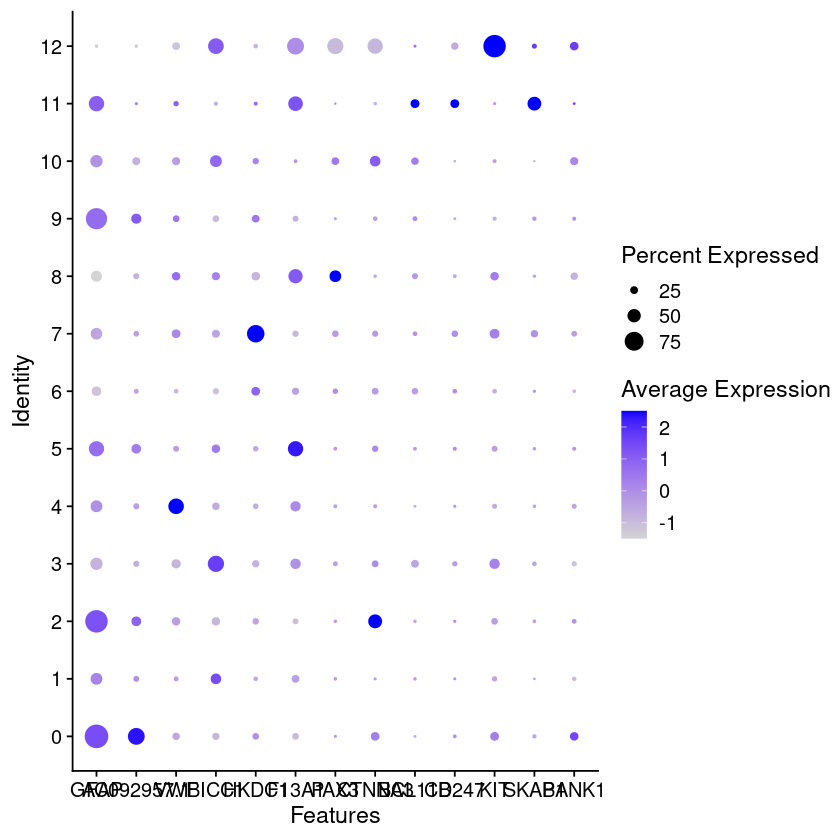

In [66]:
DotPlot(xenium.combined, features = marker_genes)

Warning message:
“The following requested variables were not found: MECOM, GABRG3, KCNQ3, ADAM28, MYH11, CARMN, RNF220, NXPH1, CSMD1, PYHIN1”


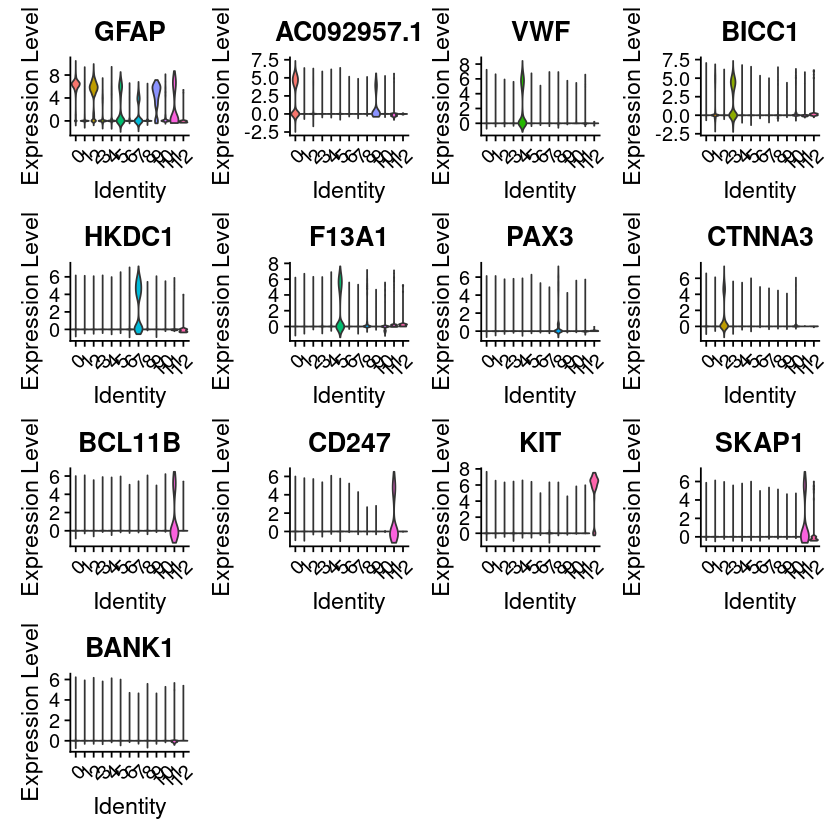

In [67]:
VlnPlot(xenium.combined, features = marker_genes, pt.size = 0)

In [68]:
saveRDS(xenium.combined, paste0(output_PATH, target_tissue, "_xenium.combined_cutoff20.rds"))

In [69]:
pdf(paste0(output_PATH, target_tissue, "_xenium_vln_dot_p5_cutoff20.pdf"), width = 6, height = 5)
VlnPlot(xenium.combined, features = marker_genes, pt.size = 0)
DotPlot(xenium.combined, features = marker_genes)
dev.off()

Warning message:
“The following requested variables were not found: MECOM, GABRG3, KCNQ3, ADAM28, MYH11, CARMN, RNF220, NXPH1, CSMD1, PYHIN1”
Warning message:
“The following requested variables were not found: MECOM, GABRG3, KCNQ3, ADAM28, MYH11, CARMN, RNF220, NXPH1, CSMD1, PYHIN1”


pdf 
  2

In [70]:
pdf(paste0(output_PATH, target_tissue, "_xenium_vln_dot_p5_cutoff20.pdf"), width = 12, height = 5)
VlnPlot(xenium.combined, features = marker_genes, pt.size = 0)
DotPlot(xenium.combined, features = marker_genes)
dev.off()

Warning message:
“The following requested variables were not found: MECOM, GABRG3, KCNQ3, ADAM28, MYH11, CARMN, RNF220, NXPH1, CSMD1, PYHIN1”
Warning message:
“The following requested variables were not found: MECOM, GABRG3, KCNQ3, ADAM28, MYH11, CARMN, RNF220, NXPH1, CSMD1, PYHIN1”


pdf 
  2